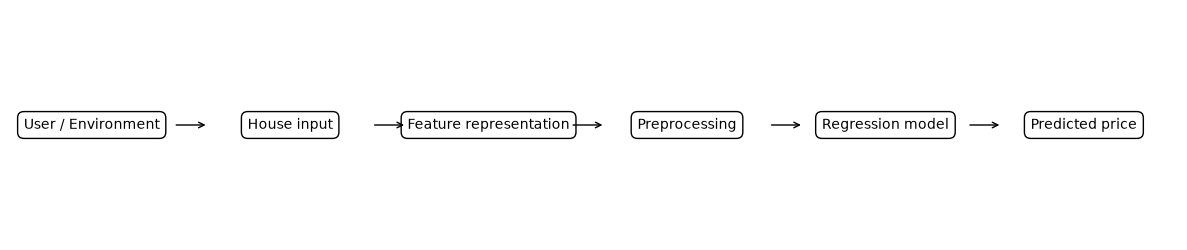

In [1]:
%matplotlib inline
import os
import re
import math
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

# System Architecture Diagram
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.axis('off')
labels = [
    'User / Environment',
    'House input',
    'Feature representation',
    'Preprocessing',
    'Regression model',
    'Predicted price'
]
xs = [0.07, 0.24, 0.41, 0.58, 0.75, 0.92]
for x, label in zip(xs, labels):
    ax.text(x, 0.5, label, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.45', fc='white', ec='black'))
for x1, x2 in zip(xs[:-1], xs[1:]):
    ax.annotate('', xy=(x2-0.07, 0.5), xytext=(x1+0.07, 0.5),
                arrowprops=dict(arrowstyle='->'))
plt.tight_layout()
plt.savefig('figures/05_system_diagram.png', dpi=160, bbox_inches='tight')
plt.show()

In [2]:
#---load data---
df = pd.read_csv('gia_nha.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 2.8 MB


In [3]:
df.head()

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [4]:
summary = pd.DataFrame({
    'Type': df.dtypes.astype(str),
    'Missing': df.isnull().sum(),
    'Unique': df.nunique(dropna=True)
})
summary

,Type,Missing,Unique
Address,str,0,10265
Area,float64,0,1512
Frontage,float64,11564,407
Access Road,float64,13297,140
House direction,str,21239,8
Balcony direction,str,24983,8
Floors,float64,3603,10
Bedrooms,float64,5162,9
Bathrooms,float64,7074,9
Legal status,str,4506,2


In [5]:
print('Target (Price) summary statistics:')
print(df['Price'].describe())

Target (Price) summary statistics:
count    30229.000000
mean         5.872078
std          2.211877
min          1.000000
25%          4.200000
50%          5.900000
75%          7.500000
max         11.500000
Name: Price, dtype: float64


In [6]:
#---check for null values---
print("Nulls")
print("=====")
print(df.isnull().sum())

Nulls
=====
Address                  0
Area                     0
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bedrooms              5162
Bathrooms             7074
Legal status          4506
Furniture state      14119
Price                    0
dtype: int64


In [7]:
#---check for 0s---
print("0s")
print("==")
print(df.select_dtypes(include=np.number).eq(0).sum())

0s
==
Area           0
Frontage       0
Access Road    0
Floors         0
Bedrooms       0
Bathrooms      0
Price          0
dtype: int64


In [8]:
# Price and Area are essential and must be positive
df = df[(df['Price'] > 0) & (df['Area'] > 0)].copy()
df.reset_index(drop=True, inplace=True)
print('Dataset shape after checking positive Price and Area:', df.shape)

Dataset shape after checking positive Price and Area: (30229, 12)


In [9]:
#---extract location features from Address---
def extract_location(address):
    parts = [re.sub(r'[.\s]+$', '', p.strip()) for p in str(address).split(',')]
    province = parts[-1] if len(parts) >= 1 and parts[-1] and parts[-1].lower() != 'nan' else 'Unknown'
    district = parts[-2] if len(parts) >= 2 and parts[-2] else 'Unknown'
    return pd.Series([province, district])

df[['Province', 'District']] = df['Address'].apply(extract_location)

numeric_cols = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
categorical_cols = [
    'House direction', 'Balcony direction', 'Legal status',
    'Furniture state', 'Province', 'District'
]
feature_cols = numeric_cols + categorical_cols

X = df[feature_cols].copy()
y = df['Price'].copy()

feature_table = pd.DataFrame([
    ['Area', 'Numerical', 'Real value', 'House area (m²)'],
    ['Frontage', 'Numerical', 'Real value', 'Frontage width (m)'],
    ['Access Road', 'Numerical', 'Real value', 'Road/access width (m)'],
    ['Floors', 'Numerical', 'Real value', 'Number of floors'],
    ['Bedrooms', 'Numerical', 'Real value', 'Number of bedrooms'],
    ['Bathrooms', 'Numerical', 'Real value', 'Number of bathrooms'],
    ['House direction', 'Categorical', 'Ordinal encoded', 'House direction'],
    ['Balcony direction', 'Categorical', 'Ordinal encoded', 'Balcony direction'],
    ['Legal status', 'Categorical', 'Ordinal encoded', 'Legal status'],
    ['Furniture state', 'Categorical', 'Ordinal encoded', 'Furniture state'],
    ['Province', 'Categorical', 'Ordinal encoded', 'Province/city extracted from Address'],
    ['District', 'Categorical', 'Ordinal encoded', 'District extracted from Address'],
], columns=['Feature', 'Type', 'Representation', 'Meaning'])
feature_table

,Feature,Type,Representation,Meaning
0,Area,Numerical,Real value,House area (m²)
1,Frontage,Numerical,Real value,Frontage width (m)
2,Access Road,Numerical,Real value,Road/access width (m)
3,Floors,Numerical,Real value,Number of floors
4,Bedrooms,Numerical,Real value,Number of bedrooms
5,Bathrooms,Numerical,Real value,Number of bathrooms
6,House direction,Categorical,Ordinal encoded,House direction
7,Balcony direction,Categorical,Ordinal encoded,Balcony direction
8,Legal status,Categorical,Ordinal encoded,Legal status
9,Furniture state,Categorical,Ordinal encoded,Furniture state


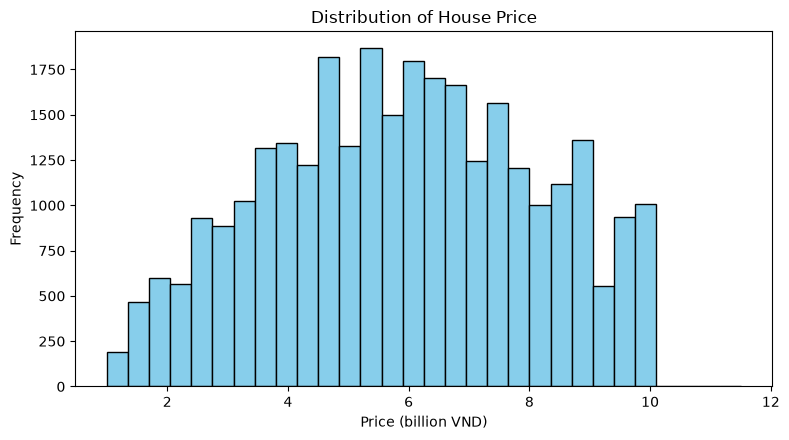

In [10]:
plt.figure(figsize=(8, 4.5))
plt.hist(df['Price'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of House Price')
plt.xlabel('Price (billion VND)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/01_price_distribution.png', dpi=160)
plt.show()

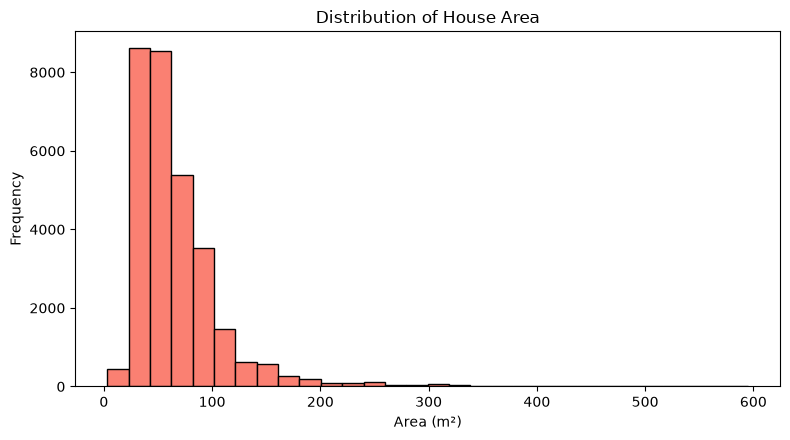

In [11]:
plt.figure(figsize=(8, 4.5))
plt.hist(df['Area'].dropna(), bins=30, color='salmon', edgecolor='black')
plt.title('Distribution of House Area')
plt.xlabel('Area (m²)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/02_area_distribution.png', dpi=160)
plt.show()

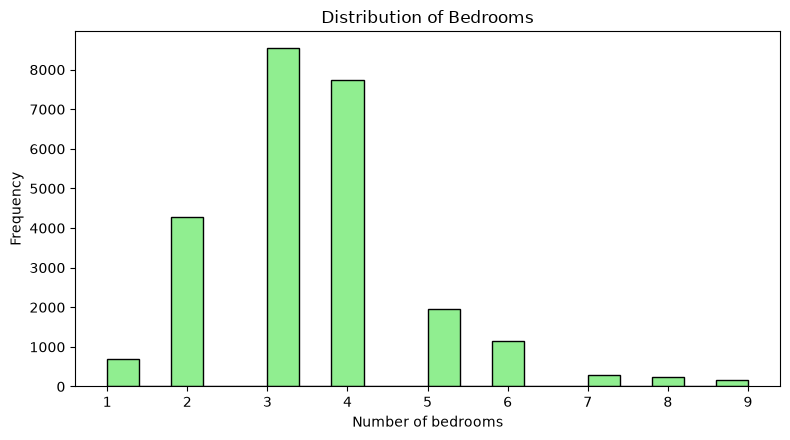

In [12]:
plt.figure(figsize=(8, 4.5))
plt.hist(df['Bedrooms'].dropna(), bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Bedrooms')
plt.xlabel('Number of bedrooms')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/03_bedrooms_distribution.png', dpi=160)
plt.show()

In [13]:
#---examining the correlation between features---
correlation_cols = numeric_cols + ['Price']
corr = df[correlation_cols].corr()
print(corr)

                 Area  Frontage  Access Road    Floors  Bedrooms  Bathrooms  \
Area         1.000000  0.261108     0.269203 -0.359341  0.029541  -0.039367   
Frontage     0.261108  1.000000     0.142082 -0.039783  0.015079   0.013736   
Access Road  0.269203  0.142082     1.000000 -0.055556  0.073892   0.072499   
Floors      -0.359341 -0.039783    -0.055556  1.000000  0.498771   0.620851   
Bedrooms     0.029541  0.015079     0.073892  0.498771  1.000000   0.782130   
Bathrooms   -0.039367  0.013736     0.072499  0.620851  0.782130   1.000000   
Price        0.097593  0.047469     0.164280  0.331639  0.389432   0.434101   

                Price  
Area         0.097593  
Frontage     0.047469  
Access Road  0.164280  
Floors       0.331639  
Bedrooms     0.389432  
Bathrooms    0.434101  
Price        1.000000  


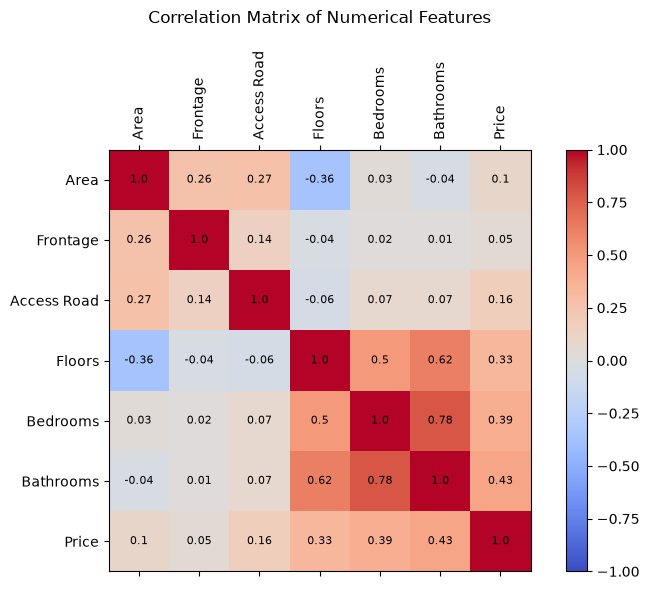

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(cax)
ticks = np.arange(len(correlation_cols))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(correlation_cols, rotation=90)
ax.set_yticklabels(correlation_cols)
for i in range(len(correlation_cols)):
    for j in range(len(correlation_cols)):
        ax.text(j, i, round(corr.iloc[i, j], 2), ha='center', va='center', fontsize=8)
plt.title('Correlation Matrix of Numerical Features', pad=20)
plt.tight_layout()
plt.savefig('figures/04_correlation_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

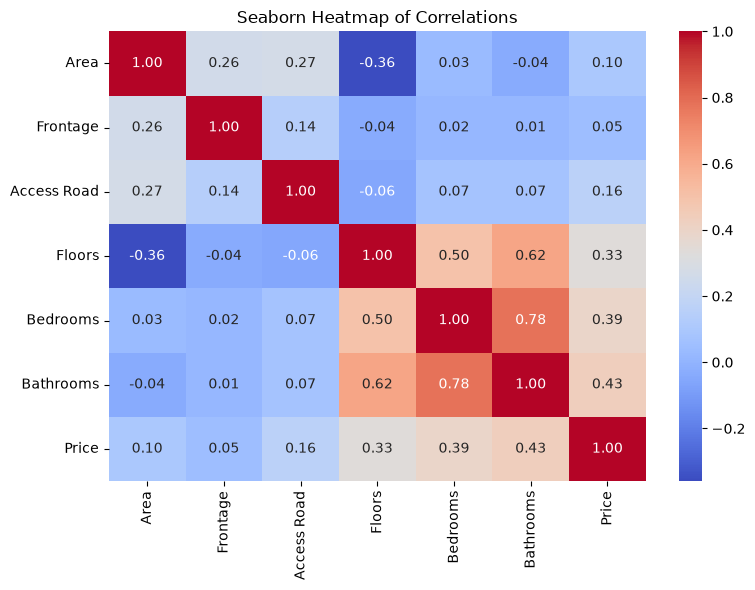

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Seaborn Heatmap of Correlations')
plt.tight_layout()
plt.show()

In [16]:
#---get top features correlated with Price---
print(corr.nlargest(len(correlation_cols), 'Price')['Price'])

Price          1.000000
Bathrooms      0.434101
Bedrooms       0.389432
Floors         0.331639
Access Road    0.164280
Area           0.097593
Frontage       0.047469
Name: Price, dtype: float64


In [17]:
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.20, random_state=42
)

print('Training rows:', len(X_train))
print('Validation rows:', len(X_val))
print('Final test rows:', len(X_test))

Training rows: 19346
Validation rows: 4837
Final test rows: 6046


In [18]:
def make_preprocessor(cat_cols):
    numerical = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])
    return ColumnTransformer([
        ('num', numerical, numeric_cols),
        ('cat', categorical, cat_cols)
    ])

preprocessor = make_preprocessor(categorical_cols)

# Fit preprocessing on TRAINING data only
X_train_ready = preprocessor.fit_transform(X_train)
X_val_ready = preprocessor.transform(X_val)
X_test_ready = preprocessor.transform(X_test)

print('Encoded training shape:', X_train_ready.shape)

Encoded training shape: (19346, 12)


In [19]:
def evaluate(y_true, prediction):
    mse = mean_squared_error(y_true, prediction)
    return {
        'MAE': mean_absolute_error(y_true, prediction),
        'MSE': mse,
        'RMSE': math.sqrt(mse),
        'R2': r2_score(y_true, prediction),
        'MAPE (%)': mean_absolute_percentage_error(y_true, prediction) * 100
    }

In [20]:
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train_ready, y_train)
baseline_prediction = baseline.predict(X_val_ready)
baseline_metrics = evaluate(y_val, baseline_prediction)
print('Baseline Metrics (Mean Predictor):')
print(baseline_metrics)

Baseline Metrics (Mean Predictor):
{'MAE': 1.83436653972539, 'MSE': 4.827294775597199, 'RMSE': 2.1971105515192444, 'R2': -4.092793978394127e-06, 'MAPE (%)': 43.73229314047844}


In [21]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0, solver='lsqr'),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=15, min_samples_leaf=3, random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=50, max_depth=18, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=50, max_depth=18, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )
}

In [22]:
rows = [['Baseline Mean', *baseline_metrics.values()]]
for name, model in models.items():
    print('Training:', name)
    model.fit(X_train_ready, y_train)
    prediction = model.predict(X_val_ready)
    metrics = evaluate(y_val, prediction)
    rows.append([name, *metrics.values()])
    print(metrics)

comparison = pd.DataFrame(
    rows,
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)']
)
comparison = comparison.sort_values('R2', ascending=False).reset_index(drop=True)
comparison.to_csv('results/model_comparison.csv', index=False)
comparison

Training: Linear Regression
{'MAE': 1.574687482918364, 'MSE': 3.715792871434051, 'RMSE': 1.9276391963835067, 'R2': 0.23025042966243003, 'MAPE (%)': 35.8366221783601}
Training: Ridge Regression
{'MAE': 1.5758980920451053, 'MSE': 3.720487014362653, 'RMSE': 1.9288564006588602, 'R2': 0.2292780088016838, 'MAPE (%)': 35.87815020493238}
Training: Decision Tree
{'MAE': 1.2141225913385607, 'MSE': 2.681858480381284, 'RMSE': 1.6376380797909178, 'R2': 0.4444363600431379, 'MAPE (%)': 25.173432265060114}
Training: Random Forest


{'MAE': 1.047520816977496, 'MSE': 1.9424229708371599, 'RMSE': 1.3937083521444362, 'R2': 0.5976150181270223, 'MAPE (%)': 21.987073463730475}
Training: Extra Trees


{'MAE': 1.155786743377843, 'MSE': 2.2102394002902614, 'RMSE': 1.486687391582461, 'R2': 0.5421351814855074, 'MAPE (%)': 24.575734088950902}


,Model,MAE,MSE,RMSE,R2,MAPE (%)
0,Random Forest,1.047521,1.942423,1.393708,0.597615,21.987073
1,Extra Trees,1.155787,2.210239,1.486687,0.542135,24.575734
2,Decision Tree,1.214123,2.681858,1.637638,0.444436,25.173432
3,Linear Regression,1.574687,3.715793,1.927639,0.230250,35.836622
4,Ridge Regression,1.575898,3.720487,1.928856,0.229278,35.878150
5,Baseline Mean,1.834367,4.827295,2.197111,-0.000004,43.732293


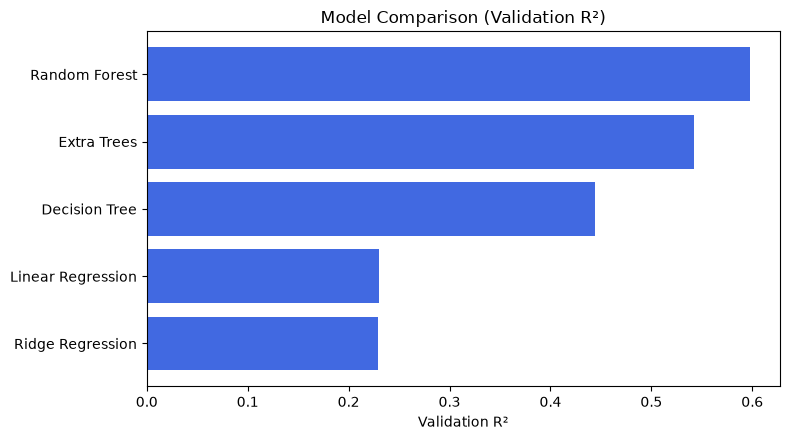

In [23]:
plot_df = comparison[comparison['Model'] != 'Baseline Mean'].sort_values('R2')
plt.figure(figsize=(8, 4.5))
plt.barh(plot_df['Model'], plot_df['R2'], color='royalblue')
plt.xlabel('Validation R²')
plt.title('Model Comparison (Validation R²)')
plt.tight_layout()
plt.savefig('figures/06_model_comparison.png', dpi=160)
plt.show()

In [24]:
best_row = comparison[comparison['Model'] != 'Baseline Mean'].iloc[0]
best_model_name = best_row['Model']
print('Best validation model:', best_model_name)
print(best_row)

Best validation model: Random Forest
Model       Random Forest
MAE              1.047521
MSE              1.942423
RMSE             1.393708
R2               0.597615
MAPE (%)        21.987073
Name: 0, dtype: object


In [25]:
hyper_rows = []
for n in [10, 30, 50]:
    rf = RandomForestRegressor(
        n_estimators=n, max_depth=18, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train_ready, y_train)
    pred = rf.predict(X_val_ready)
    m = evaluate(y_val, pred)
    hyper_rows.append([n, *m.values()])

hyper_df = pd.DataFrame(
    hyper_rows,
    columns=['n_estimators', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)']
)
hyper_df.to_csv('results/hyperparameter_experiment.csv', index=False)
hyper_df

,n_estimators,MAE,MSE,RMSE,R2,MAPE (%)
0,10,1.081609,2.066456,1.437517,0.571921,22.678983
1,30,1.053224,1.964008,1.401431,0.593144,22.078962
2,50,1.047521,1.942423,1.393708,0.597615,21.987073


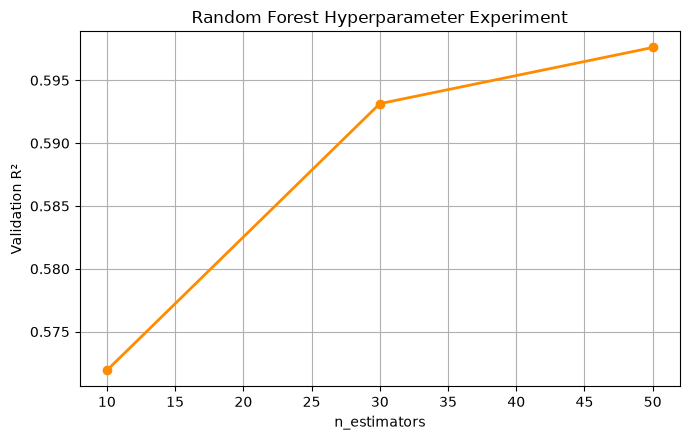

In [26]:
plt.figure(figsize=(7, 4.5))
plt.plot(hyper_df['n_estimators'], hyper_df['R2'], marker='o', color='darkorange', linewidth=2)
plt.xlabel('n_estimators')
plt.ylabel('Validation R²')
plt.title('Random Forest Hyperparameter Experiment')
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/07_hyperparameter.png', dpi=160)
plt.show()

In [27]:
base_cat_cols = ['House direction', 'Balcony direction', 'Legal status', 'Furniture state']
representation_rows = []

for label, cat_cols in [
    ('Without Province + District', base_cat_cols),
    ('With Province + District', categorical_cols)
]:
    cols = numeric_cols + cat_cols
    pre = make_preprocessor(cat_cols)
    train_ready = pre.fit_transform(X_train[cols])
    val_ready = pre.transform(X_val[cols])

    rf = RandomForestRegressor(
        n_estimators=50, max_depth=18, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )
    rf.fit(train_ready, y_train)
    pred = rf.predict(val_ready)
    m = evaluate(y_val, pred)
    representation_rows.append([label, *m.values()])

representation_df = pd.DataFrame(
    representation_rows,
    columns=['Representation', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)']
)
representation_df.to_csv('results/representation_experiment.csv', index=False)
representation_df

,Representation,MAE,MSE,RMSE,R2,MAPE (%)
0,Without Province + District,1.396394,3.122580,1.767082,0.353138,31.139083
1,With Province + District,1.047521,1.942423,1.393708,0.597615,21.987073


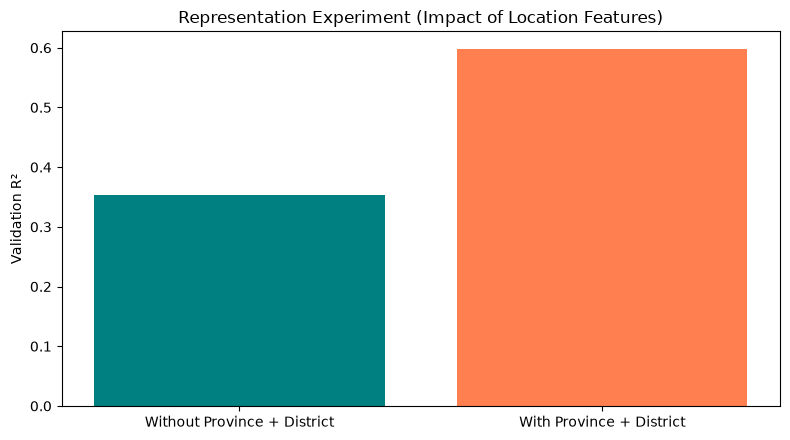

In [28]:
plt.figure(figsize=(8, 4.5))
plt.bar(representation_df['Representation'], representation_df['R2'], color=['teal', 'coral'])
plt.ylabel('Validation R²')
plt.title('Representation Experiment (Impact of Location Features)')
plt.tight_layout()
plt.savefig('figures/08_representation.png', dpi=160)
plt.show()

In [29]:
#---train final model using full training set---
final_preprocessor = make_preprocessor(categorical_cols)
X_train_all_ready = final_preprocessor.fit_transform(X_train_all)
X_test_final_ready = final_preprocessor.transform(X_test)

final_model = RandomForestRegressor(
    n_estimators=50, max_depth=18, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
final_model.fit(X_train_all_ready, y_train_all)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",18
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

In [30]:
final_prediction = final_model.predict(X_test_final_ready)
final_metrics = evaluate(y_test, final_prediction)
print('Final unseen test metrics:')
print(final_metrics)
pd.DataFrame([final_metrics]).to_csv('results/final_test_metrics.csv', index=False)

Final unseen test metrics:
{'MAE': 1.0553742117528313, 'MSE': 1.9951798296560115, 'RMSE': 1.4125083467562276, 'R2': 0.5908089750104905, 'MAPE (%)': 22.361456205316184}


In [31]:
#---save the model to disk---
bundle = {
    'preprocessor': final_preprocessor,
    'model': final_model,
    'feature_cols': feature_cols,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols
}
filename = 'house_price_model.pkl'
with open(filename, 'wb') as f:
    pickle.dump(bundle, f)

print(f"Saved: {filename}")

Saved: house_price_model.pkl


In [32]:
#---load the model from disk---
with open('house_price_model.pkl', 'rb') as f:
    loaded_bundle = pickle.load(f)

print("Model loaded successfully.")

Model loaded successfully.


In [33]:
examples = pd.DataFrame([
    {
        'Area': 50, 'Frontage': 5, 'Access Road': 6, 'Floors': 4,
        'Bedrooms': 4, 'Bathrooms': 3,
        'House direction': 'Tây', 'Balcony direction': 'Tây',
        'Legal status': 'Have certificate', 'Furniture state': 'Basic',
        'Province': 'Hồ Chí Minh', 'District': 'Bình Tân'
    },
    {
        'Area': 80, 'Frontage': 5, 'Access Road': 10, 'Floors': 5,
        'Bedrooms': 5, 'Bathrooms': 4,
        'House direction': 'Đông - Nam', 'Balcony direction': 'Đông - Nam',
        'Legal status': 'Have certificate', 'Furniture state': 'Full',
        'Province': 'Hà Nội', 'District': 'Cầu Giấy'
    },
    {
        'Area': 120, 'Frontage': 7, 'Access Road': 15, 'Floors': 3,
        'Bedrooms': 4, 'Bathrooms': 4,
        'House direction': 'Nam', 'Balcony direction': 'Nam',
        'Legal status': 'Sale contract', 'Furniture state': 'Basic',
        'Province': 'Đà Nẵng', 'District': 'Ngũ Hành Sơn'
    }
])

example_ready = loaded_bundle['preprocessor'].transform(
    examples[loaded_bundle['feature_cols']]
)
example_prices = loaded_bundle['model'].predict(example_ready)
examples['Predicted Price (billion VND)'] = np.round(example_prices, 2)
examples.to_csv('results/demo_predictions.csv', index=False)
examples

,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,House direction,Balcony direction,Legal status,Furniture state,Province,District,Predicted Price (billion VND)
0,50,5,6,4,4,3,Tây,Tây,Have certificate,Basic,Hồ Chí Minh,Bình Tân,5.72
1,80,5,10,5,5,4,Đông - Nam,Đông - Nam,Have certificate,Full,Hà Nội,Cầu Giấy,8.43
2,120,7,15,3,4,4,Nam,Nam,Sale contract,Basic,Đà Nẵng,Ngũ Hành Sơn,6.83


In [34]:
#---client prediction simulation function---
def predict_house_price(house_dict):
    sample_df = pd.DataFrame([house_dict])
    ready = loaded_bundle['preprocessor'].transform(sample_df[loaded_bundle['feature_cols']])
    price = loaded_bundle['model'].predict(ready)[0]
    return round(price, 2)

test_house = {
    'Area': 65, 'Frontage': 4.5, 'Access Road': 8, 'Floors': 3,
    'Bedrooms': 3, 'Bathrooms': 2,
    'House direction': 'Nam', 'Balcony direction': 'Nam',
    'Legal status': 'Have certificate', 'Furniture state': 'Full',
    'Province': 'Hà Nội', 'District': 'Đống Đa'
}
predicted = predict_house_price(test_house)
print(f"Predicted price for test house: {predicted} billion VND")

Predicted price for test house: 6.17 billion VND
